In [1]:
import os
import sys
from pathlib import Path
import numpy as np

# Get the project root directory (parent of notebooks folder)
project_root = str(Path(os.getcwd()).resolve().parent.parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from tqdm import tqdm
import torch
import torch.optim as optim
import torch.nn as nn
# from torch.utils.data import Subset
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchsummary import summary

from vgg16_practice.src.load_data import split_dataset
from vgg16_practice.src.data_classes import TrainingConfig

# from models.vgg16 import VGG16
# from models.resnet import ResNetLayer

# from vgg16_practice.src.train import Trainer

### create dataset 

In [2]:
# CIFAR10 dataset
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load from already downloaded dataset (set download=False)
# CIFAR-10 will be in data_path/cifar-10-batches-py/
data_path = os.path.join(sys.path[0], 'Data')
dataset_train = datasets.CIFAR10(root=data_path, train=True, download=False, transform=transform)
dataset_test = datasets.CIFAR10(root=data_path, train=False, download=False, transform=transform)

print(f"Training samples: {len(dataset_train)}")
print(f"Test samples: {len(dataset_test)}")

/opt/miniconda3/envs/vgg16_with_py311/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 50000
Test samples: 10000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.5632443].


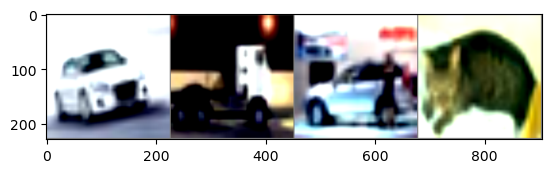

car   truck car   cat  


In [3]:
import numpy as np
import matplotlib.pyplot as plt

import torchvision
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

trainloader = DataLoader(dataset_train, batch_size=4, shuffle=True)

# 학습용 이미지를 무작위로 가져오기
dataiter = iter(trainloader)
images, labels = next(dataiter)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


NUM_CLASSES = len(classes)

# 이미지 보여주기
imshow(torchvision.utils.make_grid(images))
# 정답(label) 출력
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))


### Split dataset into training and validation sets, then create DataLoaders

In [4]:
train_dataset, val_dataset = split_dataset(dataset_train, train_ratio=0.8)

# Optional: Create subset for quick testing/debugging
USE_SUBSET = True  # Set to True for quick testing
SUBSET_SIZE = 1000  # Number of samples to use
BALANCED_SUBSET = True  # Set to True for balanced class distribution

if USE_SUBSET:
    from torch.utils.data import Subset
    
    if BALANCED_SUBSET:
        # Create balanced subset with equal samples per class
        samples_per_class = SUBSET_SIZE // NUM_CLASSES
        
        # Collect indices for each class
        train_class_indices = {i: [] for i in range(NUM_CLASSES)}
        for idx in range(len(train_dataset)):
            _, label = train_dataset[idx]
            train_class_indices[label].append(idx)
        
        # Sample equally from each class
        train_indices = []
        for class_idx in range(NUM_CLASSES):
            class_samples = train_class_indices[class_idx][:samples_per_class]
            train_indices.extend(class_samples)
        
        # Do the same for validation
        val_samples_per_class = (SUBSET_SIZE // 5) // NUM_CLASSES  # 20% of training subset
        val_class_indices = {i: [] for i in range(NUM_CLASSES)}
        for idx in range(len(val_dataset)):
            _, label = val_dataset[idx]
            val_class_indices[label].append(idx)
        
        val_indices = []
        for class_idx in range(NUM_CLASSES):
            class_samples = val_class_indices[class_idx][:val_samples_per_class]
            val_indices.extend(class_samples)
        
        print(f"Using BALANCED SUBSET mode:")
        print(f"  Samples per class: {samples_per_class} (train), {val_samples_per_class} (val)")
    else:
        # Unbalanced subset (just take first N samples)
        train_indices = list(range(min(SUBSET_SIZE, len(train_dataset))))
        val_indices = list(range(min(SUBSET_SIZE // 5, len(val_dataset))))
        print(f"Using UNBALANCED SUBSET mode:")
    
    train_dataset = Subset(train_dataset, train_indices)
    val_dataset = Subset(val_dataset, val_indices)
    print(f"  Train samples: {len(train_dataset)}")
    print(f"  Val samples: {len(val_dataset)}")

Training set size: 40000
Validation set size: 10000
Using BALANCED SUBSET mode:
  Samples per class: 100 (train), 20 (val)
  Train samples: 1000
  Val samples: 200
Using BALANCED SUBSET mode:
  Samples per class: 100 (train), 20 (val)
  Train samples: 1000
  Val samples: 200


### Setting up training configuration 

In [13]:
# Configuration for training
config = TrainingConfig(
    batch_size=32,
    num_epochs=10,
    num_train_samples=len(train_dataset),  # Set from your dataset
    lr_scheduler_epoch=10,
    learning_rate=1e-4,
    weight_decay=1e-4,
    save_path=os.path.join(sys.path[0], 'Data', 'checkpoints')
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(os.path.exists(config.save_path))


Train batches: 32
Validation batches: 7
False


### Configure device as MPS on MacBook Air M4

In [14]:
#Configure loss function, optimizer, and learning rate scheduler
if torch.backends.mps.is_available():    
    device = torch.device("mps")
    # Set MPS environment variables for performance tuning
    # Limit the number of threads used by MPS
    os.environ['MPS_NUM_THREADS'] = '6'  # Adjust based on your M-series chip (4, 8, or 10)
    print(f"Using device: {device}")
    print(f"MPS threads set to: {os.environ.get('MPS_NUM_THREADS', 'default')}")
else:
    device = torch.device("cpu")
    print(f"Using device: {device}")

Using device: mps
MPS threads set to: 6


### Setting up for transfer learning 

Load a pretrained VGG16 model from torchvision,

In this model, only classifier layers will be fine-tuned

In [15]:
from torchvision import models

# load pretrained VGG16 model from torchvision, where weights='default' uses pretrained weights on ImageNet1K_V1
model = models.vgg16(weights='DEFAULT')

# freeze all layers first 
for param in model.parameters():
    param.requires_grad = False

# unfreeze the last layer of the classifier
model.classifier[3].requires_grad_ = True

# customize the last layer of the classifier to match the number of classes
model.classifier[6] = nn.Sequential(
                      nn.Linear(4096, 512), 
                      nn.ReLU(), 
                      nn.Dropout(0.5),
                      nn.Linear(512, NUM_CLASSES))

model = model.to(device)
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)

Summary for the model is not displayed when device is MPS

In [16]:
# if device.type == 'cpu':
#     summary(model, (3, 224, 224))

### Set up a loss function and optimizer 

In [17]:
# lr_scheduler_step_size = config.lr_scheduler_step_size()
# print(lr_scheduler_step_size)

total_steps = config.total_steps()
print(f"total number of steps: {total_steps}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
# scheduler = StepLR(optimizer, step_size=config.lr_scheduler_step_size, gamma=0.5)

total number of steps: 310


### Train with validation dataset 

In [18]:

def compute_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for features, labels in data_loader:
            features, labels = features.to(device), labels.to(device)
            logits = model(features)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


def compute_epoch_loss(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    num_examples = 0
    for features, labels in data_loader:
        features, labels = features.to(device), labels.to(device)
        logits = model(features)
        loss = criterion(logits, labels)
        epoch_loss += loss.item()
        num_examples += features.size(0)
    return epoch_loss / num_examples



for epoch in range(config.num_epochs):
    # ==================== TRAINING ====================
    model.train()
    epoch_train_loss = 0.0

    ProgressBar = tqdm(enumerate(train_loader), total=len(train_loader))

    for batch_idx, (inputs, labels) in ProgressBar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(inputs)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

        # Update Progress bar (only training loss during training)
        ProgressBar.set_description(f'Epoch [{epoch+1}/{config.num_epochs}]')
        ProgressBar.set_postfix(TrainLoss=loss.item())

    # Average training loss for the epoch
    avg_train_loss = epoch_train_loss / len(train_loader)

    # ==================== VALIDATION (Once per epoch) ====================
    print(f"\nRunning validation for epoch {epoch+1}...")
    with torch.no_grad():
        avg_val_acc = compute_accuracy(model, val_loader, device)
        avg_val_loss = compute_epoch_loss(model, val_loader, criterion, device)

    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")
    print(f"  Val Acc:    {avg_val_acc:.4f}")


Epoch [1/10]: 100%|██████████| 32/32 [00:12<00:00,  2.56it/s, TrainLoss=1.69]




Running validation for epoch 1...

Epoch 1 Summary:
  Train Loss: 2.0270
  Val Loss:   0.0572
  Val Acc:    0.6800

Epoch 1 Summary:
  Train Loss: 2.0270
  Val Loss:   0.0572
  Val Acc:    0.6800


Epoch [2/10]: 100%|██████████| 32/32 [00:12<00:00,  2.59it/s, TrainLoss=1.13]




Running validation for epoch 2...

Epoch 2 Summary:
  Train Loss: 1.4222
  Val Loss:   0.0401
  Val Acc:    0.7150

Epoch 2 Summary:
  Train Loss: 1.4222
  Val Loss:   0.0401
  Val Acc:    0.7150


Epoch [3/10]: 100%|██████████| 32/32 [00:12<00:00,  2.62it/s, TrainLoss=1.07] 



...


Running validation for epoch 8...

Epoch 8 Summary:
  Train Loss: 0.6155
  Val Loss:   0.0241
  Val Acc:    0.7350

Epoch 8 Summary:
  Train Loss: 0.6155
  Val Loss:   0.0241
  Val Acc:    0.7350


Epoch [9/10]: 100%|██████████| 32/32 [00:12<00:00,  2.53it/s, TrainLoss=0.419]




Running validation for epoch 9...

Epoch 9 Summary:
  Train Loss: 0.5723
  Val Loss:   0.0235
  Val Acc:    0.7250

Epoch 9 Summary:
  Train Loss: 0.5723
  Val Loss:   0.0235
  Val Acc:    0.7250


Epoch [10/10]: 100%|██████████| 32/32 [00:12<00:00,  2.61it/s, TrainLoss=0.306]




Running validation for epoch 10...

Epoch 10 Summary:
  Train Loss: 0.5486
  Val Loss:   0.0238
  Val Acc:    0.7300

Epoch 10 Summary:
  Train Loss: 0.5486
  Val Loss:   0.0238
  Val Acc:    0.7300


In [19]:
test_loader = DataLoader(dataset_test, batch_size=config.batch_size, shuffle=False)

with torch.set_grad_enabled(False): # save memory during inference
    print('Test accuracy: %.2f%%' % (compute_accuracy(model, test_loader, device)*100))

Test accuracy: 76.90%


In [29]:
from sklearn.metrics import classification_report



In [30]:
model.eval()
all_labels = []
all_predictions = []
with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        logits = model(features)
        _, predicted = torch.max(logits.data, 1)

        # Move to CPU and convert to numpy for sklearn
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Total test samples evaluated: {len(all_labels)}")
print(f"Total predictions collected: {len(all_predictions)}")


Total test samples evaluated: 10000
Total predictions collected: 10000


In [31]:
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

In [32]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# Calculate metrics
f1_macro = f1_score(all_labels, all_predictions, average='macro')
f1_micro = f1_score(all_labels, all_predictions, average='micro')
f1_weighted = f1_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
accuracy = accuracy_score(all_labels, all_predictions)

print("=" * 50)
print("Model Performance Metrics on Test Set")
print("=" * 50)
print(f"Accuracy:           {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted):    {recall:.4f}")
print(f"F1-Score (macro):     {f1_macro:.4f}")
print(f"F1-Score (micro):     {f1_micro:.4f}")
print(f"F1-Score (weighted):  {f1_weighted:.4f}")
print("=" * 50)

Model Performance Metrics on Test Set
Accuracy:           0.7770 (77.70%)
Precision (weighted): 0.7789
Recall (weighted):    0.7770
F1-Score (macro):     0.7765
F1-Score (micro):     0.7770
F1-Score (weighted):  0.7765


In [33]:
# Detailed classification report with per-class metrics
print("\nDetailed Classification Report:")
print("=" * 70)
print(classification_report(all_labels, all_predictions, target_names=classes, digits=4))

# Per-class F1 scores
f1_per_class = f1_score(all_labels, all_predictions, average=None)
print("\nPer-Class F1 Scores:")
print("=" * 70)
for i, class_name in enumerate(classes):
    print(f"{class_name:10s}: {f1_per_class[i]:.4f}")


Detailed Classification Report:
              precision    recall  f1-score   support

       plane     0.8232    0.7450    0.7822      1000
         car     0.8416    0.8820    0.8613      1000
        bird     0.7568    0.6720    0.7119      1000
         cat     0.6458    0.6710    0.6582      1000
        deer     0.6782    0.7630    0.7181      1000
         dog     0.7830    0.7290    0.7550      1000
        frog     0.7859    0.8370    0.8107      1000
       horse     0.8345    0.7310    0.7793      1000
        ship     0.8266    0.8530    0.8396      1000
       truck     0.8130    0.8870    0.8484      1000

    accuracy                         0.7770     10000
   macro avg     0.7789    0.7770    0.7765     10000
weighted avg     0.7789    0.7770    0.7765     10000


Per-Class F1 Scores:
plane     : 0.7822
car       : 0.8613
bird      : 0.7119
cat       : 0.6582
deer      : 0.7181
dog       : 0.7550
frog      : 0.8107
horse     : 0.7793
ship      : 0.8396
truck     : 0.8

In [20]:
for batch_idx, (features, targets) in enumerate(test_loader):

    features = features
    targets = targets
    break

logits = model(features.to(device))
_, predicted_labels = torch.max(logits, 1)
    

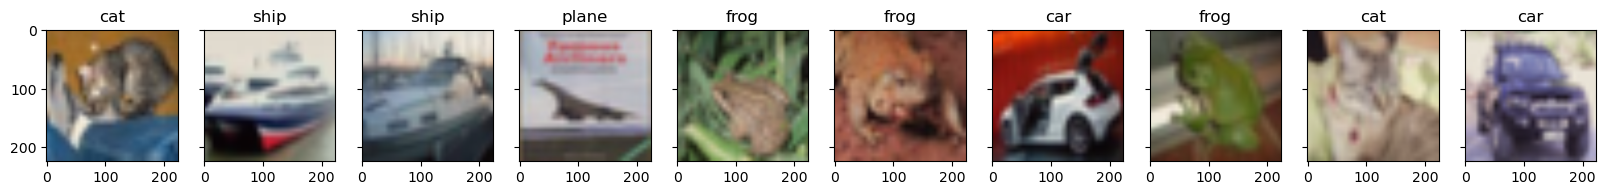

In [21]:
def unnormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

n_images = 10

fig, axes = plt.subplots(nrows=1, ncols=n_images, 
                         sharex=True, sharey=True, figsize=(20, 2.5))
orig_images = features[:n_images]

for i in range(n_images):
    curr_img = orig_images[i].detach().to('cpu')
    curr_img = unnormalize(curr_img,
                           torch.tensor([0.485, 0.456, 0.406]),
                           torch.tensor([0.229, 0.224, 0.225])) 
    curr_img = curr_img.permute((1, 2, 0))
    axes[i].imshow(curr_img)
    axes[i].set_title(classes[predicted_labels[i]])